In [1]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np

In [ ]:
def converged_flux(da, t_start, time_dim="time", n_blocks=None):
    """
    Converged value + 1-sigma uncertainty of a saturated turbulence time trace.

    da       : 1D xarray.DataArray of Q(t) (already reduced to a single time series)
    t_start  : time after which the trace is saturated (discard transient before this)
    n_blocks : number of blocks for block-averaging. If None, chosen as ~T/(5*tau_c).

    Returns a dict with the mean, its 1-sigma standard error (sem), the correlation
    time, the effective number of independent samples, and the relative error.
    """
    q = da.where(da[time_dim] >= t_start, drop=True)
    t = q[time_dim].values
    y = np.asarray(q.values, dtype=float)
    N = y.size
    mean = y.mean()

    # --- integrated autocorrelation time (in samples) ---
    yc = y - mean
    acf = np.correlate(yc, yc, mode="full")[N - 1:]
    acf /= acf[0]
    # integrate ACF up to first zero crossing (avoids the noisy tail)
    first_neg = np.argmax(acf < 0)
    cutoff = first_neg if first_neg > 0 else N
    tau_int = 1.0 + 2.0 * acf[1:cutoff].sum()        # in units of samples
    dt = np.median(np.diff(t))
    tau_c = tau_int * dt                             # correlation time in time units
    N_eff = N / max(tau_int, 1.0)

    # --- block (batch-means) standard error ---
    if n_blocks is None:
        n_blocks = max(4, int(N / (5 * max(tau_int, 1.0))))   # >= 5 tau per block
    n_blocks = min(n_blocks, N)
    edges = np.array_split(np.arange(N), n_blocks)
    block_means = np.array([y[idx].mean() for idx in edges])
    sem = block_means.std(ddof=1) / np.sqrt(len(block_means))

    return {
        "mean": mean,
        "sem": sem,                 # 1-sigma uncertainty on the mean
        "tau_c": tau_c,             # correlation time (same units as t)
        "N_eff": N_eff,             # effective independent samples
        "n_blocks": len(block_means),
        "rel_err_%": 100 * sem / abs(mean),
    }


# Example: converged heat flux for one gamma_exb value
# da = (project_dict["nl_exb_scan"]["S1"].gk_output["heat"]
#         .sum(dim="species").sum(dim="field").isel(gamma_exb=5))
# res = converged_flux(da, t_start=200.0)   # set t_start from the Q(t) plot
# print("Q = %.3g +/- %.2g  (%.1f%%, N_eff=%.0f, tau_c=%.1f)" % (
#     res["mean"], res["sem"], res["rel_err_%"], res["N_eff"], res["tau_c"]))


In [2]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [3]:
cases = ["M1_A1","S1"]
projects = ["nl_exb_scan"]

In [4]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        json_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.nc"))
        gene_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
        gene_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        case_dict[case] = gene_pyoscan
        project_dict[project] = case_dict

/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0000'. 
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0001) is inconsistent with value from physical reference values (0.09617910133883377 beta_ref_ee_B0_pyroscan_base0001)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0001'. 
  warnings.warn(


In [5]:
tglf_versions = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules = ["sat1","sat2","sat3"]
tglf_grid_models = [1,4]
width_neg = [0,1]
tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            sat_rules = {}
            for sat_rule in tglf_sat_rules:
                grid_models = {}
                for grid_model in tglf_grid_models:
                    json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/{version}/{sat_rule}_kygrid{grid_model}/pyroscan.json"))
                    net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/{version}/{sat_rule}_kygrid{grid_model}/pyroscan.nc"))
                    try:
                        tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                        tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                        grid_models[grid_model] = tglf_pyoscan
                    except Exception as e:
                        print(f"Error loading pyroscan for {project}/{case}/{version}/{sat_rule}_kygrid{grid_model}: {e}")
                sat_rules[sat_rule] = grid_models
            version_dict[version] = sat_rules
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Error loading pyroscan for nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid1/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid4/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid1/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid4/pyroscan.json'
Error loading pyroscan for nl_exb_scan/S1/tglf_default_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/da

Error plotting tglf_default_negwm sat1 grid model 1: 1
Error plotting tglf_default_negwm sat1 grid model 4: 4
Error plotting tglf_v1_negwm sat1 grid model 1: 1
Error plotting tglf_v1_negwm sat1 grid model 4: 4


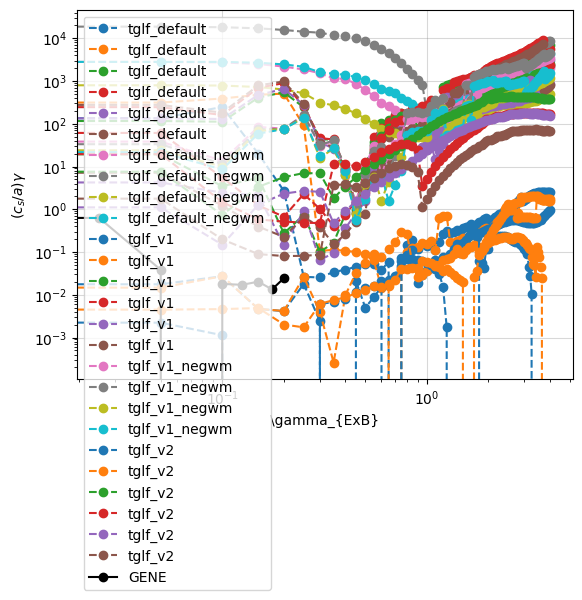

In [8]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "S1"
reference_exb = 3.49


for tglf in tglf_versions:
    for sat_rule in tglf_sat_rules:
        for grid_model in tglf_grid_models:
            try:
                (tglf_project_dict[project][case][tglf][sat_rule][grid_model]
                    .gk_output["heat"].sum(dim="species").sum(dim="field")
                    .plot(label=tglf, marker="o", linestyle="--"))
            except Exception as e:
                print(f"Error plotting {tglf} {sat_rule} grid model {grid_model}: {e}")



project_dict[project][case].gk_output["heat"].sum(dim="species").sum(dim="field").plot(label="GENE", color="black", marker="o")



#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.xlabel(r"\gamma_{ExB}")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
plt.yscale("log")
plt.xscale("log")
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
/home/Felix/Document

Plotting tglf_default sat2 grid model 4
Plotting tglf_default_negwm sat2 grid model 4
Plotting tglf_v1 sat2 grid model 4
Plotting tglf_v1_negwm sat2 grid model 4
Plotting tglf_v2 sat2 grid model 4


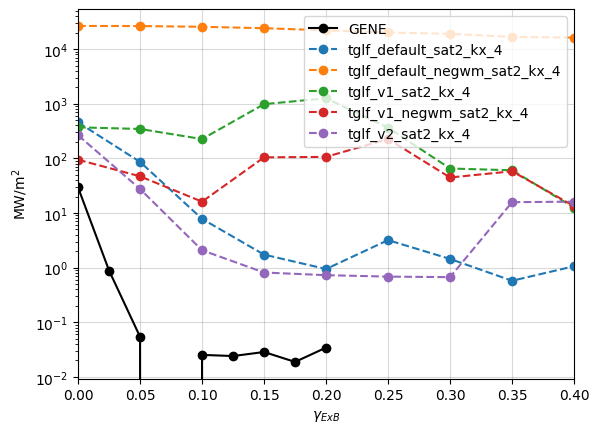

In [15]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "S1"
reference_exb = 3.49

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


GENE_context = project_dict[project][case].base_pyro.norms.context

GENE_Heat = project_dict[project][case].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2",GENE_context)
GENE_exb = project_dict[project][case].gk_output["heat"]["gamma_exb"]
plt.plot(GENE_exb,np.abs(GENE_Heat), label="GENE", color="black", marker="o")

for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            print(f"Plotting {tglf} {sat_rule} grid model {grid_model}")
            try:
                tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2",GENE_context)
                tglf_exb = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"]["gamma_exb"]
                plt.plot(tglf_exb, np.abs(tglf_heat), label=f"{tglf}_{sat_rule}_kx_{grid_model}", marker="o", linestyle="--")
            except Exception as e:
                print(f"Error plotting {tglf} {sat_rule} grid model {grid_model}: {e}")




#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.ylabel(r"MW/m$^2$")
plt.xlabel(r"$\gamma_{ExB}$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
plt.yscale("log")
#plt.xscale("log")
plt.xlim(GENE_exb[0],2*GENE_exb[-1])
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



In [ ]:
import xarray as xr
from matplotlib import pyplot as plt

# GENE heat-flux scan with converged-value error bars
project = "nl_exb_scan"
case = "S1"
t_start_frac = 0.4   # discard this leading fraction of each trace as transient

# PyroScan holding the TIME-RESOLVED GENE heat flux (must have a 'time' dim).
# Use project_dict_full[...] if that is where your time traces live.
gene_scan = project_dict[project][case]
GENE_context = gene_scan.base_pyro.norms.context

heat = gene_scan.gk_output["heat"].sum(dim="species").sum(dim="field")

# detect the time dimension (everything that isn't the scan axis)
time_dim = "time" if "time" in heat.dims else [d for d in heat.dims if d != "gamma_exb"][0]

gammas, means, errs = [], [], []
for i, g in enumerate(heat["gamma_exb"].values):
    trace = heat.isel(gamma_exb=i)
    # convert this trace to MW/m^2, keep the time coordinate
    trace_si = xr.DataArray(
        np.asarray(trace.data.to("MW/m^2", GENE_context)),
        coords={time_dim: trace[time_dim].values}, dims=[time_dim])
    t = trace_si[time_dim].values
    t0 = t[0] + t_start_frac * (t[-1] - t[0])
    res = converged_flux(trace_si, t_start=t0, time_dim=time_dim)
    gammas.append(float(g))
    means.append(res["mean"])
    errs.append(res["sem"])

gammas = np.asarray(gammas)
means = np.asarray(means)
errs = np.asarray(errs)

plt.errorbar(gammas, np.abs(means), yerr=errs, label="GENE",
             color="black", marker="o", capsize=3)
plt.xlabel(r"$\gamma_{ExB}$")
plt.ylabel(r"MW/m$^2$")
plt.yscale("log")
plt.grid(alpha=0.3, color="grey")
plt.legend()


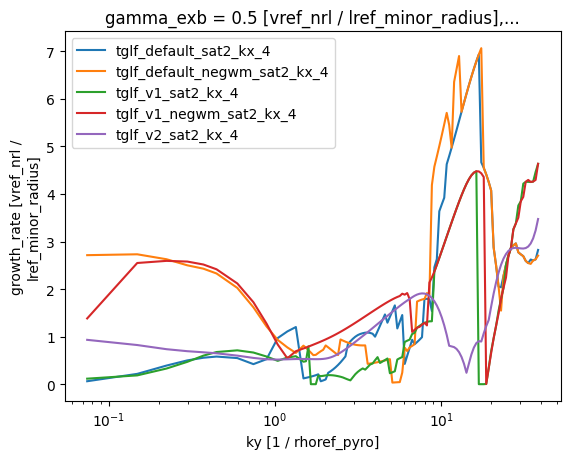

In [75]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_exb = 3.49

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["growth_rate"].isel(gamma_exb=10).isel(mode=0).plot(label=f"{tglf}_{sat_rule}_kx_{grid_model}")

plt.legend()
plt.xscale("log")

In [22]:
cases = ["M1_A1_NE"]
projects = ["scan_beta"]
gs2_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.nc"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    gs2_project_dict[project] = case_dict

Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0056'. 
  warnings.warn(


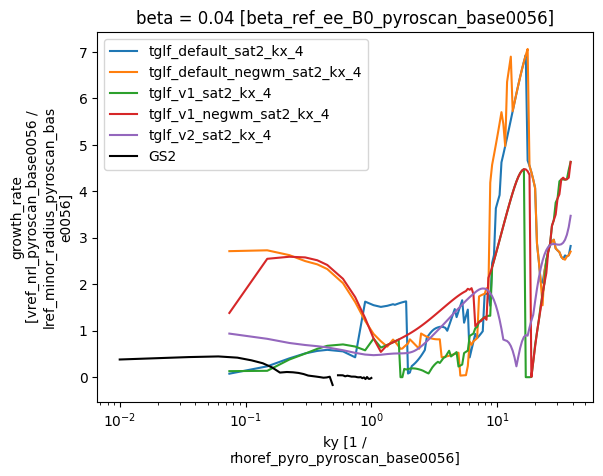

In [26]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_beta = 0.036

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["growth_rate"].isel(gamma_exb=10).isel(mode=0).plot(label=f"{tglf}_{sat_rule}_kx_{grid_model}")

gs2_project_dict["scan_beta"]["M1_A1_NE"].gk_output["growth_rate"].sel(beta=reference_beta,method="nearest").plot(label="GS2", color="black")

plt.legend()
plt.xscale("log")